In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Load The Dataset

In [2]:
df = pd.read_csv("AmesHousing.csv")
print(df.shape)
df.head()

(2930, 82)


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


# Check Missing Values

In [3]:
VM = pd.DataFrame({
'Colonne': df.columns.values,
'nbr_VM': df.isna().sum().values,
'%_VM': 100 * df.isna().sum().values / len(df)
})

VM = VM[VM['nbr_VM'] > 0]
print(VM.sort_values(by='nbr_VM', ascending=False))

           Colonne  nbr_VM       %_VM
73         Pool QC    2917  99.556314
75    Misc Feature    2824  96.382253
7            Alley    2732  93.242321
74           Fence    2358  80.477816
26    Mas Vnr Type    1775  60.580205
58    Fireplace Qu    1422  48.532423
4     Lot Frontage     490  16.723549
64     Garage Qual     159   5.426621
65     Garage Cond     159   5.426621
60   Garage Yr Blt     159   5.426621
61   Garage Finish     159   5.426621
59     Garage Type     157   5.358362
33   Bsmt Exposure      83   2.832765
36  BsmtFin Type 2      81   2.764505
32       Bsmt Cond      80   2.730375
31       Bsmt Qual      80   2.730375
34  BsmtFin Type 1      80   2.730375
27    Mas Vnr Area      23   0.784983
48  Bsmt Full Bath       2   0.068259
49  Bsmt Half Bath       2   0.068259
35    BsmtFin SF 1       1   0.034130
37    BsmtFin SF 2       1   0.034130
43      Electrical       1   0.034130
39   Total Bsmt SF       1   0.034130
38     Bsmt Unf SF       1   0.034130
63     Garag

In [4]:
df = df.dropna(axis=1, thresh=len(df)*0.7)

In [5]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].mean())

In [6]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [7]:
df = pd.get_dummies(df)

In [8]:
y = df['SalePrice']
X = df.drop('SalePrice', axis=1)

# Split Data

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42)

# Standarization

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train Model

In [11]:
model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=[X_train.shape[1]]),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [13]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    validation_split=0.2
)

Epoch 1/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 37611782144.0000 - mae: 177880.8125 - val_loss: 38170877952.0000 - val_mae: 179997.5312
Epoch 2/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 37338468352.0000 - mae: 177532.8125 - val_loss: 37270138880.0000 - val_mae: 178075.4062
Epoch 3/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 35806171136.0000 - mae: 174015.2500 - val_loss: 31759333376.0000 - val_mae: 165675.7812
Epoch 4/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 28973451264.0000 - mae: 157293.4531 - val_loss: 18532311040.0000 - val_mae: 127380.1328
Epoch 5/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 14319861760.0000 - mae: 109668.0859 - val_loss: 8890525696.0000 - val_mae: 78775.0078
Epoch 6/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7669407744.0000 - mae: 73326.9062 - val_loss: 6109022720.0000 - val_mae: 64161.4961
Epoch 7/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5517316096.0000 - mae: 60708.7070 - val_loss: 4271166720.0000 - v

In [14]:
loss, mae = model.evaluate(X_test, y_test)
print("Test MAE:", mae)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1088646144.0000 - mae: 19014.5840
Test MAE: 18667.91796875


# Plot Training Results

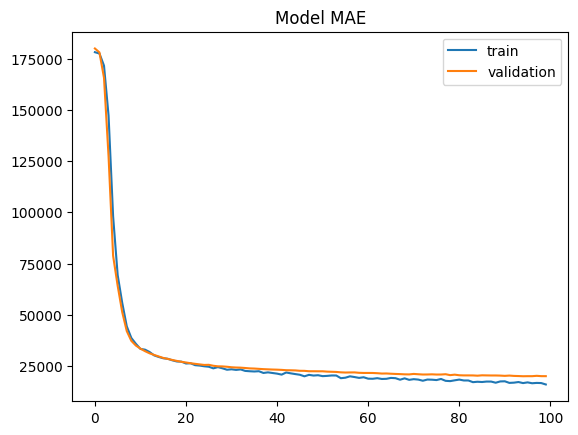

In [15]:
plt.plot(history.history['mae'])
plt.plot(history.history['val_mae'])
plt.legend(['train','validation'])
plt.title("Model MAE")
plt.show()

# Prediction

In [20]:
prediction = model.predict(X_test[1:2])
print("Prediction:", prediction)
print("Real value:", y_test.iloc[1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
Prediction: [[118266.73]]
Real value: 116000
